=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB

=== DESCRIBE (numeryczne) ===


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000



=== DESCRIBE (wszystkie kolumny) ===


,total_bill,tip,sex,smoker,day,time,size
count,244.000000,244.000000,244,244,244,244,244.000000
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000



=== BRAKUJĄCE WARTOŚCI ===
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

=== ŚREDNI RACHUNEK I NAPIWEK WG DNIA I PŁCI ===


C:\Users\karol\AppData\Local\Temp\ipykernel_7056\1150386313.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["day", "sex"])


,day,sex,total_bill_mean,tip_mean
0,Thur,Male,18.71,2.98
1,Thur,Female,16.72,2.58
2,Fri,Male,19.86,2.69
3,Fri,Female,14.15,2.78
4,Sat,Male,20.80,3.08
5,Sat,Female,19.68,2.80
6,Sun,Male,21.89,3.22
7,Sun,Female,19.87,3.37



=== ŚREDNI PROCENT NAPIWKU WG (day, time) ===


C:\Users\karol\AppData\Local\Temp\ipykernel_7056\1150386313.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["day", "time"])["tip_rate"]


,day,time,tip_rate_mean,tip_rate_mean_pct
0,Thur,Lunch,0.161301,16.13
1,Thur,Dinner,0.159744,15.97
2,Fri,Lunch,0.188765,18.88
3,Fri,Dinner,0.158916,15.89
4,Sat,Lunch,NaN,NaN
5,Sat,Dinner,0.153152,15.32
6,Sun,Lunch,NaN,NaN
7,Sun,Dinner,0.166897,16.69


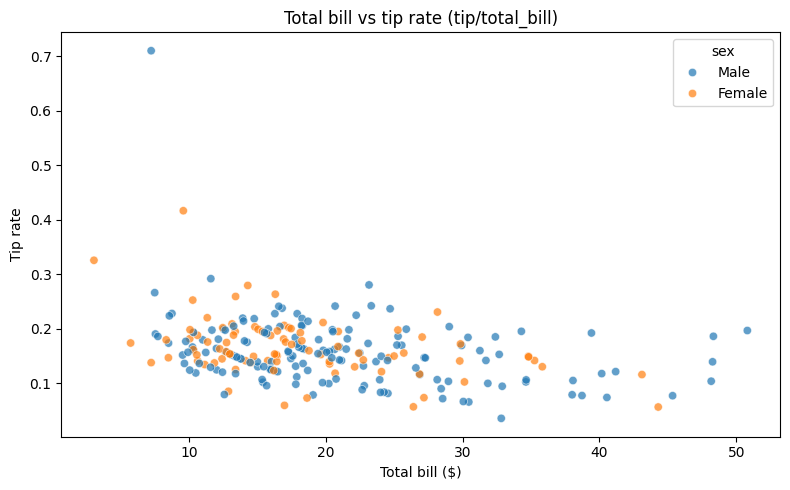


=== WNIOSKI (do użycia w komórce Markdown) ===
- Średni tip_rate weekend:  0.160
- Średni tip_rate weekday:  0.163
→ Napiwki procentowo NIE są wyższe w weekendy.
- Wyższe napiwki procentowe zostawiają: Female.


In [2]:
# ---- 1) Importy i wczytanie danych ----
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")  # wbudowany zbiór z Seaborn
# (opcjonalnie) podejrzyj pierwsze wiersze:
# display(df.head())

# ---- 2) Podstawowe informacje + statystyki + braki ----
print("=== INFO ===")
df.info()

print("\n=== DESCRIBE (numeryczne) ===")
display(df.describe())

print("\n=== DESCRIBE (wszystkie kolumny) ===")
display(df.describe(include="all"))

print("\n=== BRAKUJĄCE WARTOŚCI ===")
print(df.isnull().sum())

# ---- 3) Średni rachunek i napiwek wg dnia tygodnia i płci ----
group_stats = (
    df.groupby(["day", "sex"])
      .agg(total_bill_mean=("total_bill", "mean"),
           tip_mean=("tip", "mean"))
      .round(2)
      .reset_index()
)
print("\n=== ŚREDNI RACHUNEK I NAPIWEK WG DNIA I PŁCI ===")
display(group_stats)

# ---- 4) Kolumna tip_rate oraz średni % napiwku wg (day, time) ----
df["tip_rate"] = df["tip"] / df["total_bill"]

avg_tip_rate = (
    df.groupby(["day", "time"])["tip_rate"]
      .mean()
      .reset_index()
      .rename(columns={"tip_rate": "tip_rate_mean"})
)
avg_tip_rate["tip_rate_mean_pct"] = (avg_tip_rate["tip_rate_mean"] * 100).round(2)

print("\n=== ŚREDNI PROCENT NAPIWKU WG (day, time) ===")
display(avg_tip_rate)

# ---- 5) Wykres punktowy: total_bill vs tip_rate (kolor = płeć) ----
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="total_bill", y="tip_rate", hue="sex", alpha=0.7)
plt.title("Total bill vs tip rate (tip/total_bill)")
plt.xlabel("Total bill ($)")
plt.ylabel("Tip rate")
plt.tight_layout()
plt.show()

# ---- 6) Prosta odpowiedź w konsoli (pomoc do Markdown) ----
# weekend vs dni robocze
weekend_mean = df[df["day"].isin(["Sat", "Sun"])]["tip_rate"].mean()
weekday_mean = df[~df["day"].isin(["Sat", "Sun"])]["tip_rate"].mean()

# wyższe napiwki % wg płci
by_sex = df.groupby("sex", observed=False)["tip_rate"].mean().sort_values(ascending=False)

print("\n=== WNIOSKI (do użycia w komórce Markdown) ===")
print(f"- Średni tip_rate weekend:  {weekend_mean:.3f}")
print(f"- Średni tip_rate weekday:  {weekday_mean:.3f}")
if weekend_mean > weekday_mean:
    print("→ Napiwki procentowo są wyższe w weekendy.")
else:
    print("→ Napiwki procentowo NIE są wyższe w weekendy.")

top_group = by_sex.index[0]
print(f"- Wyższe napiwki procentowe zostawiają: {top_group}.")